[tutorial](https://academy.lucedaphotonics.com/training/topical_training/siepic_mzi_ybranch/2_mzi)


[mzi with ybranch](https://academy.lucedaphotonics.com/training/topical_training/siepic_mzi_ybranch/)


[consecutive mzi with different delay](https://academy.lucedaphotonics.com/training/topical_training/siepic_mzi_dc_sweep/)

In [1]:
from siepic import all as pdk
from ipkiss3 import all as i3
import numpy as np

def get_angle(straight_length, delay_length, initial_angle):
    total_length = straight_length + delay_length
    initial_angle_rad = initial_angle * np.pi / 180.0

    def f(angle_rad):
        return np.abs(angle_rad / np.sin(angle_rad) - total_length / straight_length)

    from scipy.optimize import minimize

    res = minimize(
        f,
        x0=initial_angle_rad,
        bounds=((0, np.pi / 2),),
    ).x[0]
    angle = abs(res) * 180.0 / np.pi

    return angle

# Instantiating the components


In [2]:
# 1. First, we instantiate the Y-branch from the SiEPICfab PDK.
splitter = pdk.EbeamY1550()
splitter_tt = splitter.Layout().ports["opt2"].trace_template

# 2. We instantiate the waveguides we will use for the arms of the MZI.
straight_length = 200.0
delay_length = 20.0
bump_angle = get_angle(straight_length=straight_length, delay_length=delay_length, initial_angle=10.0)

wg_straight = pdk.WaveguideStraight(wg_length=straight_length, trace_template=splitter_tt)
wg_bump = pdk.WaveguideBump(x_offset=straight_length, angle=bump_angle, trace_template=splitter_tt)


# 3. We define the cells that make up our circuit. We have 2 Y-branches, one bump waveguide and one straight waveguide.
# 4. We snap the ports to each other by using `i3.Join`.
# Other placement specifications define all the transformations that apply to each instance.
specs = [
    i3.Inst(["yb_1", "yb_2"], splitter),
    i3.Inst("wg_up", wg_bump),
    i3.Inst("wg_down", wg_straight),
    i3.Join("yb_1:opt2", "wg_up:pin1"),
    i3.Join("wg_up:pin2", "yb_2:opt2"),
    i3.Join("yb_1:opt3", "wg_down:pin1"),
    i3.Join("wg_down:pin2", "yb_2:opt3"),
    i3.Place("yb_1:opt1", (0, 0)),
    i3.FlipH("yb_2"),
]

# 5. We define the names of the external ports that we want to access.
exposed_port_names = {
    "yb_1:opt1": "in",
    "yb_2:opt1": "out",
}

# 6. We instantiate the i3.Circuit class to create the circuit.
my_circuit = i3.Circuit(
    name="mzi",
    specs=specs,
    exposed_ports=exposed_port_names,
)

# Circuit layout and simulation

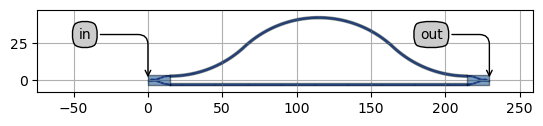

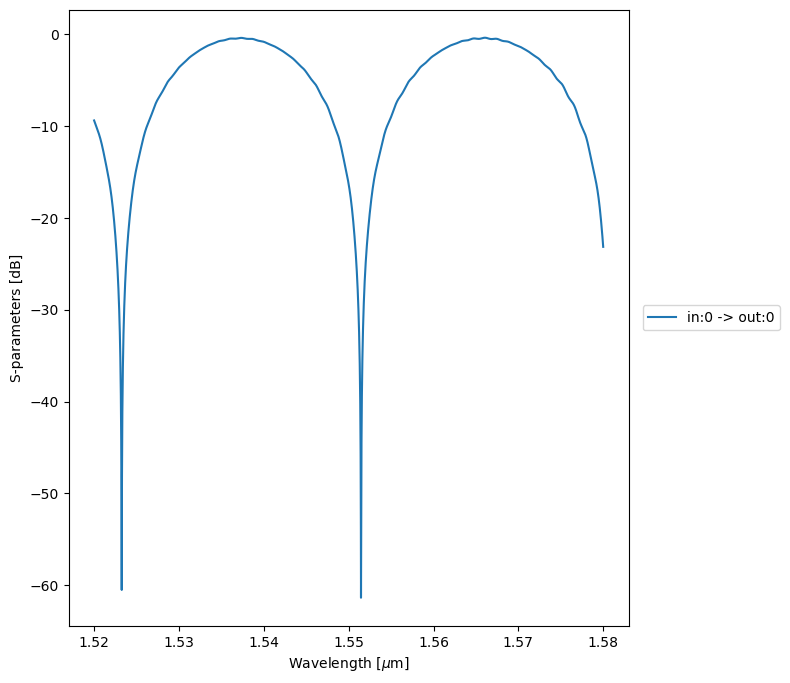

In [3]:
# Layout
my_circuit_layout = my_circuit.Layout()
my_circuit_layout.visualize(annotate=True)
my_circuit_layout.write_gdsii("EBeam_NicolasCasteleyn_mzi.gds")

# Circuit model
my_circuit_cm = my_circuit.CircuitModel()
wavelengths = np.linspace(1.52, 1.58, 4001)
S_total = my_circuit_cm.get_smatrix(wavelengths=wavelengths)

# Plotting
S_total.visualize(
    term_pairs=[
        ("in:0", "out:0"),  # TE transmission
    ],
    scale="dB",
)

# MZI in class form

In [4]:
class MZI(i3.Circuit):
    
    # 2. We instantiate the waveguides we will use for the arms of the MZI.
    straight_length = i3.PositiveNumberProperty(default=200.0)
    delay_length = i3.PositiveNumberProperty(default=20.0)
    initial_angle = i3.PositiveNumberProperty(default=10.0)

    def _default_specs(self):
        splitter = pdk.EbeamY1550()

        # variable parameters        
        straight_length = self.straight_length
        delay_length = self.delay_length
        bump_angle = get_angle(straight_length=self.straight_length, delay_length=self.delay_length, initial_angle=self.initial_angle)

        # Get the trace template from the splitter
        trace_template_splitter = splitter.Layout().ports["opt2"].trace_template

        wg_straight = pdk.WaveguideStraight(wg_length=straight_length, trace_template=trace_template_splitter)
        wg_bump = pdk.WaveguideBump(x_offset=straight_length, angle=bump_angle, trace_template=trace_template_splitter)

        # 3. We define the cells that make up our circuit. We have 2 Y-branches, one bump waveguide and one straight waveguide.
        # 4. We snap the ports to each other by using `i3.Join`.
        # Other placement specifications define all the transformations that apply to each instance.
        return [
            i3.Inst(["yb_1", "yb_2"], splitter),
            i3.Inst("wg_up", wg_bump),
            i3.Inst("wg_down", wg_straight),
            i3.Join("yb_1:opt2", "wg_up:pin1"),
            i3.Join("wg_up:pin2", "yb_2:opt2"),
            i3.Join("yb_1:opt3", "wg_down:pin1"),
            i3.Join("wg_down:pin2", "yb_2:opt3"),
            i3.Place("yb_1:opt1", (0, 0)),
            i3.FlipH("yb_2"),
        ]

    # 5. We define the names of the external ports that we want to access.
    def _default_exposed_ports(self):
        exposed_ports = {
                            "yb_1:opt1": "in",
                            "yb_2:opt1": "out",
        }
        return exposed_ports

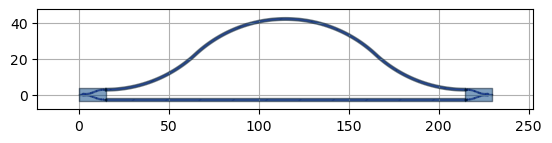

In [5]:
interferometer = MZI()  # instantiate the SplitterTree class
interferometer_layout = interferometer.Layout()  # call the Layout() method of the SplitterTree class
interferometer_layout.visualize()  # call visualize to display the layout

## use of the parametric layout

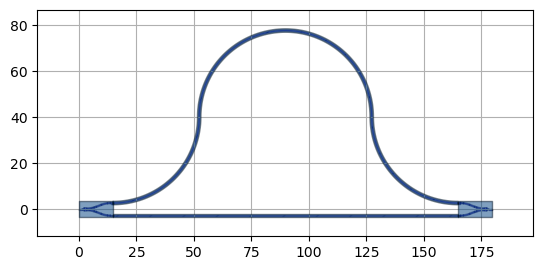

c:\Users\admin\OneDrive - UPV\EDX_140425\edx\1.5_photonic_circuit\3_design_proposal\EBeam_NicolasCasteleyn_my_mzi_design.gds

In [6]:
# Create the MZI with a custom delay
my_mzi = MZI(straight_length=150.0, delay_length=100.0)

# Generate the layout
mzi_layout = my_mzi.Layout()

# Visualize
mzi_layout.visualize()

# Export to GDS
mzi_layout.write_gdsii("EBeam_NicolasCasteleyn_my_mzi_design.gds")

## MZI with DC coupler

In [7]:
class MZI_DC(i3.Circuit):
    
    # 2. We instantiate the waveguides we will use for the arms of the MZI.
    straight_length = i3.PositiveNumberProperty(default=200.0)
    delay_length = i3.PositiveNumberProperty(default=20.0)
    initial_angle = i3.PositiveNumberProperty(default=10.0)

    def _default_specs(self):
        dc = pdk.EbeamDCTE1550()

        # variable parameters        
        straight_length = self.straight_length
        delay_length = self.delay_length
        bump_angle = get_angle(straight_length=self.straight_length, delay_length=self.delay_length, initial_angle=self.initial_angle)

        # Get the trace template from the splitter
        trace_template_splitter = dc.Layout().ports["opt2"].trace_template

        wg_straight = pdk.WaveguideStraight(wg_length=straight_length, trace_template=trace_template_splitter)
        wg_bump = pdk.WaveguideBump(x_offset=straight_length, angle=bump_angle, trace_template=trace_template_splitter)

        # 3. We define the cells that make up our circuit. We have 2 Y-branches, one bump waveguide and one straight waveguide.
        # 4. We snap the ports to each other by using `i3.Join`.
        # Other placement specifications define all the transformations that apply to each instance.
        return [
            i3.Inst(["dc_1", "dc_2"], dc),
            i3.Inst("wg_up", wg_bump),
            i3.Inst("wg_down", wg_straight),
            i3.Join("dc_1:opt3", "wg_up:pin1"),
            i3.Join("wg_up:pin2", "dc_2:opt3"),
            i3.Join("dc_1:opt4", "wg_down:pin1"),
            i3.Join("wg_down:pin2", "dc_2:opt4"),
            i3.Place("dc_1:opt1", (0, 0)),
            i3.FlipH("dc_2"),
        ]

    # 5. We define the names of the external ports that we want to access.
    def _default_exposed_ports(self):
        exposed_ports = {
                            "dc_1:opt1": "in",
                            "dc_2:opt1": "out",
        }
        return exposed_ports

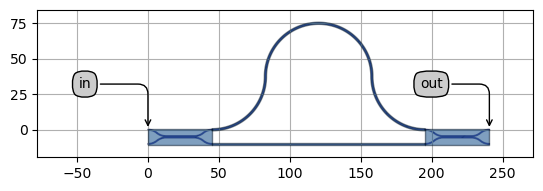

c:\Users\admin\OneDrive - UPV\EDX_140425\edx\1.5_photonic_circuit\3_design_proposal\EBeam_NicolasCasteleyn_mzi_dc_design.gds

In [8]:
# Create the MZI with a custom delay
my_mzi = MZI_DC(straight_length=150.0, delay_length=100.0)

# Generate the layout
mzi_layout = my_mzi.Layout()

# Visualize
mzi_layout.visualize(annotate=True)

# Export to GDS
mzi_layout.write_gdsii("EBeam_NicolasCasteleyn_mzi_dc_design.gds")

# MZI examples

- [mzi filter](https://academy.lucedaphotonics.com/ipkiss/picazzo/filters/mzi/ref/picazzo3.filters.mzi.cell.MZI)


- [thermal mzi](https://academy.lucedaphotonics.com/ipkiss/samples/plot_thermal_mzi)


- [lattice mzi](https://academy.lucedaphotonics.com/training/topical_training/wdm_transmitter_mzi/mzi_lattice_filter)


- [MZM](https://academy.lucedaphotonics.com/training/topical_training/mzm/)


# autre

- [mmi](https://academy.lucedaphotonics.com/training/topical_training/device_optimization_mmi/)

- [guide](https://academy.lucedaphotonics.com/ipkiss/guides/)


# important notions

[trace template](https://academy.lucedaphotonics.com/ipkiss/picazzo/traces/)

# Define mmi

In [ ]:
# PCell
class MMI1x2(i3.PCell):
    """
    MMI 1x2 with a delay in one arm.
    """
    _name_prefix = "MMI1x2"
    trace_template = i3.TraceTemplateProperty(doc="Trace template for the waveguides.")

    width = i3.PositiveNumberProperty(default=0.5, doc="Width of the MMI.")
    length = i3.PositiveNumberProperty(default=20.0, doc="Length of the MMI.")
    taper_width = i3.PositiveNumberProperty(default=1.0, doc="Width of the tapers.")
    taper_length = i3.PositiveNumberProperty(default=1.0, doc="Length of the tapers.")
    waveguide_spacing = i3.PositiveNumberProperty(default=2.0, doc="Spacing between the waveguides.")

    # layoutView Class
    class Layout(i3.LayoutView):
    
    # View-specific mehods
        def _generate_instances(self):
            splitter = pdk.EbeamY1550()
            splitter_tt = splitter.Layout().ports["opt2"].trace_template

            wg_straight = pdk.WaveguideStraight(wg_length=straight_length, trace_template=splitter_tt)
            wg_bump = pdk.WaveguideBump(x_offset=straight_length, angle=bump_angle, trace_template=splitter_tt)

            self.splitter = splitter.Layout()
            self.wg_straight = wg_straight.Layout()
            self.wg_bump = wg_bump.Layout()